# DCASE 2025 — Dataset Exploration & Signal Analysis
### Blind Device Normalization for Acoustic Scene Classification

This notebook systematically explores the TAU Urban Acoustic Scenes 2022 Mobile dataset and builds the visual evidence for our novel contribution: characterizing recording devices from signal-level features alone, without any device label.

**Sections:**
1. Dataset overview & class distribution
2. Device imbalance analysis
3. Audio waveform comparison across devices
4. Mel spectrogram comparison across devices (Figure 1 of paper)
5. Frequency response analysis per device
6. Signal feature extraction & validation (Figure 2 of paper)
7. Scene-wise signal feature analysis
8. Model parameter check

In [1]:
import os, sys
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
from src.signal_features.extractor import extract_device_features, FEATURE_NAMES

# Paths
DATASET_ROOT = '../data/raw/TAU-urban-acoustic-scenes-2022-mobile-development'
# meta.csv stores filenames as 'audio/xxx.wav' so join with DATASET_ROOT, not audio/
AUDIO_DIR    = DATASET_ROOT
META_CSV     = os.path.join(DATASET_ROOT, 'meta.csv')
FIGURES_DIR  = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

SR = 22050

DEVICE_COLORS = {
    'a':  '#2196F3',
    'b':  '#FF5722',
    'c':  '#4CAF50',
    's1': '#9C27B0', 's2': '#FF9800', 's3': '#00BCD4',
    's4': '#795548', 's5': '#607D8B', 's6': '#E91E63'
}
SCENE_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12,
                     'axes.labelsize': 11, 'figure.dpi': 120})
print('Setup complete.')
print('Dataset root exists:', os.path.exists(DATASET_ROOT))
print('Audio dir exists   :', os.path.exists(os.path.join(DATASET_ROOT, 'audio')))
# Verify a real file resolves correctly
sample_path = os.path.join(DATASET_ROOT, 'audio/airport-lisbon-1000-40000-0-a.wav')
print('Sample file exists :', os.path.exists(sample_path))

Setup complete.
Dataset root exists: True
Audio dir exists   : True
Sample file exists : True


---
## 1. Dataset Overview & Class Distribution

In [2]:
meta = pd.read_csv(META_CSV, sep='\t')
meta['device'] = meta['filename'].apply(lambda f: f.split('-')[-1].replace('.wav','').lower())
meta['city']   = meta['filename'].apply(lambda f: f.split('-')[1])

print(f'Total files : {len(meta):,}')
print(f'Scene classes: {meta["scene_label"].nunique()}')
print(f'Devices      : {sorted(meta["device"].unique())}')
print(f'Cities       : {sorted(meta["city"].unique())}')
meta.head()

Total files : 230,350
Scene classes: 10
Devices      : ['a', 'b', 'c', 's1', 's2', 's3', 's4', 's5', 's6']
Cities       : ['barcelona', 'helsinki', 'lisbon', 'london', 'lyon', 'milan', 'paris', 'prague', 'stockholm', 'vienna']


,filename,scene_label,identifier,source_label,device,city
0,audio/airport-lisbon-1000-40000-0-a.wav,airport,lisbon-1000,a,a,lisbon
1,audio/airport-lisbon-1000-40000-1-a.wav,airport,lisbon-1000,a,a,lisbon
2,audio/airport-lisbon-1000-40000-2-a.wav,airport,lisbon-1000,a,a,lisbon
3,audio/airport-lisbon-1000-40000-3-a.wav,airport,lisbon-1000,a,a,lisbon
4,audio/airport-lisbon-1000-40000-4-a.wav,airport,lisbon-1000,a,a,lisbon


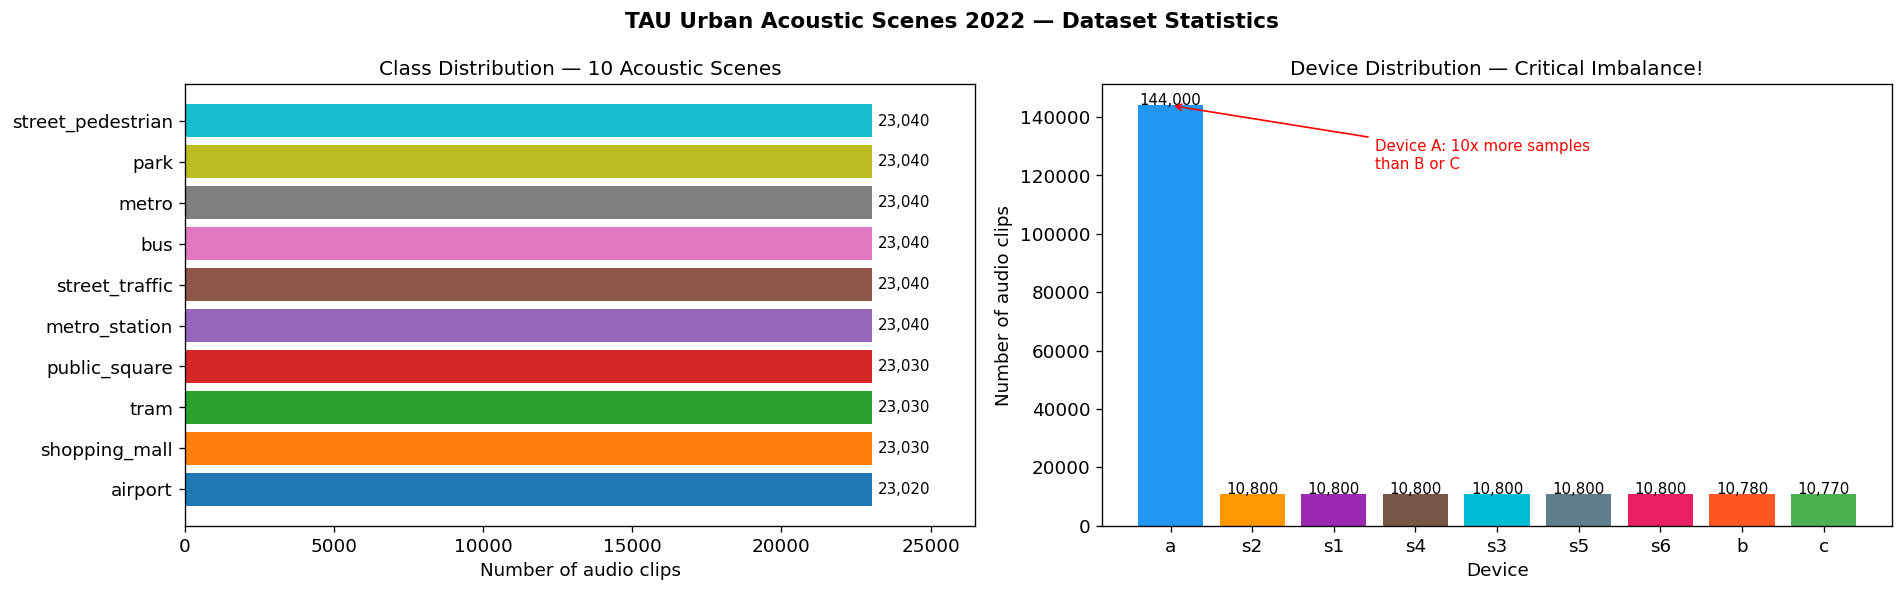

Saved → figures/01_dataset_distribution.png

Device A clips: 144,000
Device B clips: 10,780  (7.5% of A)
Device C clips: 10,770  (7.5% of A)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scene distribution
scene_counts = meta['scene_label'].value_counts().sort_values(ascending=True)
bars = axes[0].barh(scene_counts.index, scene_counts.values,
                    color=SCENE_COLORS[:len(scene_counts)])
axes[0].set_xlabel('Number of audio clips')
axes[0].set_title('Class Distribution — 10 Acoustic Scenes')
for bar, val in zip(bars, scene_counts.values):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlim(0, scene_counts.max() * 1.15)

# Device distribution — KEY point: massive imbalance
device_counts = meta['device'].value_counts().sort_values(ascending=False)
bar_colors = [DEVICE_COLORS.get(d, '#888') for d in device_counts.index]
bars2 = axes[1].bar(device_counts.index, device_counts.values, color=bar_colors)
axes[1].set_xlabel('Device')
axes[1].set_ylabel('Number of audio clips')
axes[1].set_title('Device Distribution — Critical Imbalance!')
for bar, val in zip(bars2, device_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=9)

# Annotate the imbalance
axes[1].annotate('Device A: 10x more samples\nthan B or C',
                 xy=(0, device_counts['a']), xytext=(2.5, device_counts['a'] * 0.85),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)

plt.suptitle('TAU Urban Acoustic Scenes 2022 — Dataset Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/01_dataset_distribution.png')
print(f'\nDevice A clips: {device_counts["a"]:,}')
print(f'Device B clips: {device_counts["b"]:,}  ({device_counts["b"]/device_counts["a"]*100:.1f}% of A)')
print(f'Device C clips: {device_counts["c"]:,}  ({device_counts["c"]/device_counts["a"]*100:.1f}% of A)')

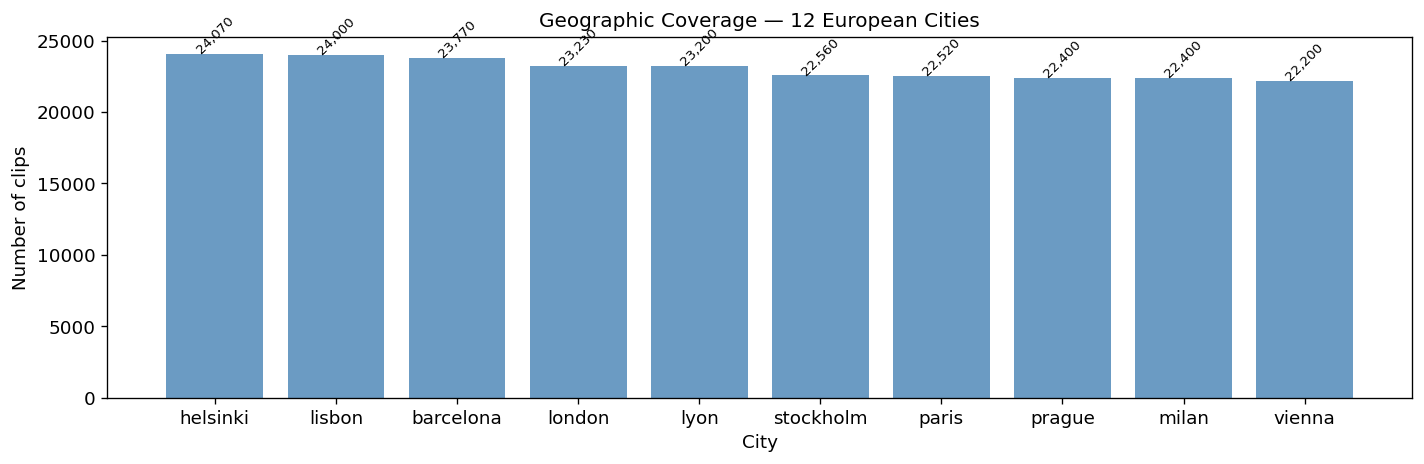

Saved → figures/02_city_distribution.png


In [4]:
# City distribution
fig, ax = plt.subplots(figsize=(12, 4))
city_counts = meta['city'].value_counts().sort_values(ascending=False)
ax.bar(city_counts.index, city_counts.values, color='steelblue', alpha=0.8)
ax.set_xlabel('City')
ax.set_ylabel('Number of clips')
ax.set_title('Geographic Coverage — 12 European Cities')
for i, (city, val) in enumerate(city_counts.items()):
    ax.text(i, val + 50, f'{val:,}', ha='center', fontsize=8, rotation=45)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_city_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/02_city_distribution.png')

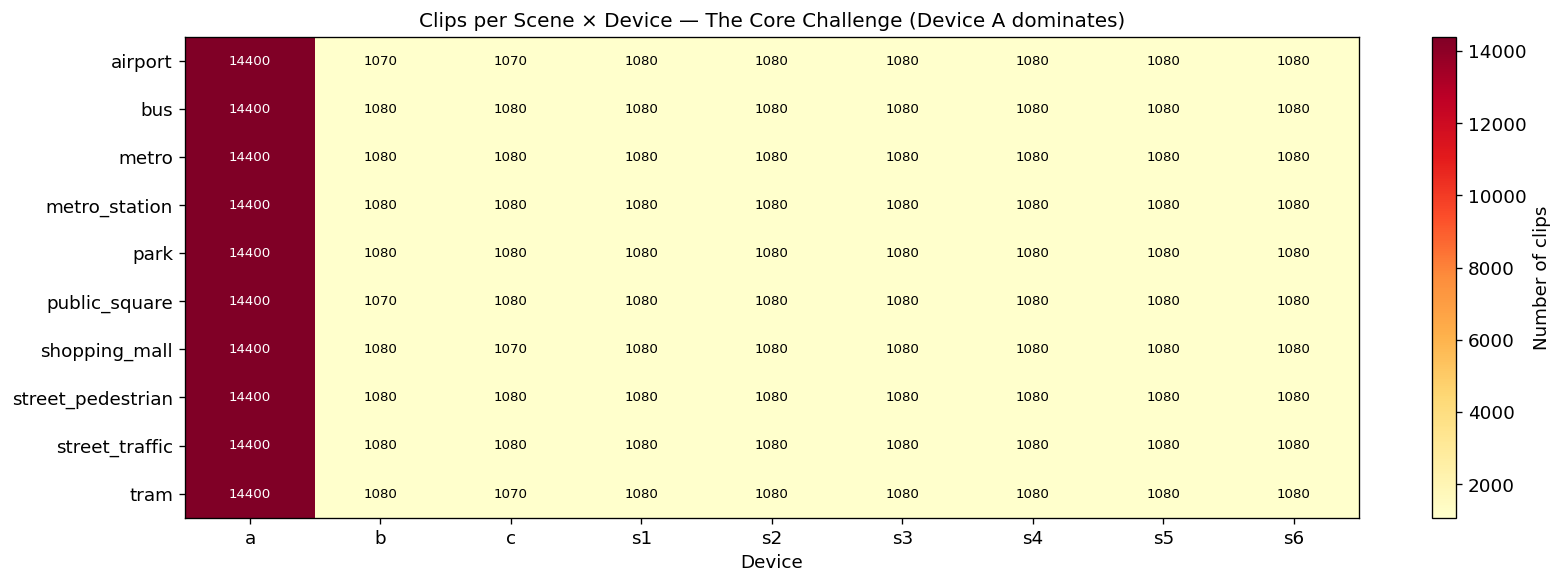

Saved → figures/03_scene_device_heatmap.png

This heatmap directly motivates our problem: the model trains mostly on Device A
but must generalize to B, C, S1-S6 — which look acoustically different.


In [5]:
# Scene × Device heatmap — shows which device covers which scene
pivot = meta.groupby(['scene_label', 'device']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Device')
ax.set_title('Clips per Scene × Device — The Core Challenge (Device A dominates)')
plt.colorbar(im, ax=ax, label='Number of clips')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, str(pivot.values[i, j]), ha='center', va='center', fontsize=8,
                color='white' if pivot.values[i, j] > pivot.values.max()*0.6 else 'black')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_scene_device_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/03_scene_device_heatmap.png')
print('\nThis heatmap directly motivates our problem: the model trains mostly on Device A')
print('but must generalize to B, C, S1-S6 — which look acoustically different.')

---
## 2. Load Audio Samples — Same Scene, Different Devices

In [6]:
# Load one clip of the same airport recording from devices A, B, C
SCENE = 'airport'
DEVICES = ['a', 'b', 'c']

airport_files = meta[meta['scene_label'] == SCENE]
audio_samples = {}

for device in DEVICES:
    row = airport_files[airport_files['device'] == device].iloc[0]
    path = os.path.join(AUDIO_DIR, row['filename'])
    audio, _ = librosa.load(path, sr=SR, mono=True, duration=1.0)
    if len(audio) < SR:
        audio = np.pad(audio, (0, SR - len(audio)))
    audio_samples[device] = audio
    print(f'Device {device.upper()}: {path.split("/")[-1]}')

print('\nAll three devices loaded for scene:', SCENE)

Device A: airport-lisbon-1000-40000-0-a.wav
Device B: airport-barcelona-1-41-0-b.wav
Device C: airport-barcelona-1-33-0-c.wav

All three devices loaded for scene: airport


---
## 3. Waveform Comparison — Same Scene, Different Devices

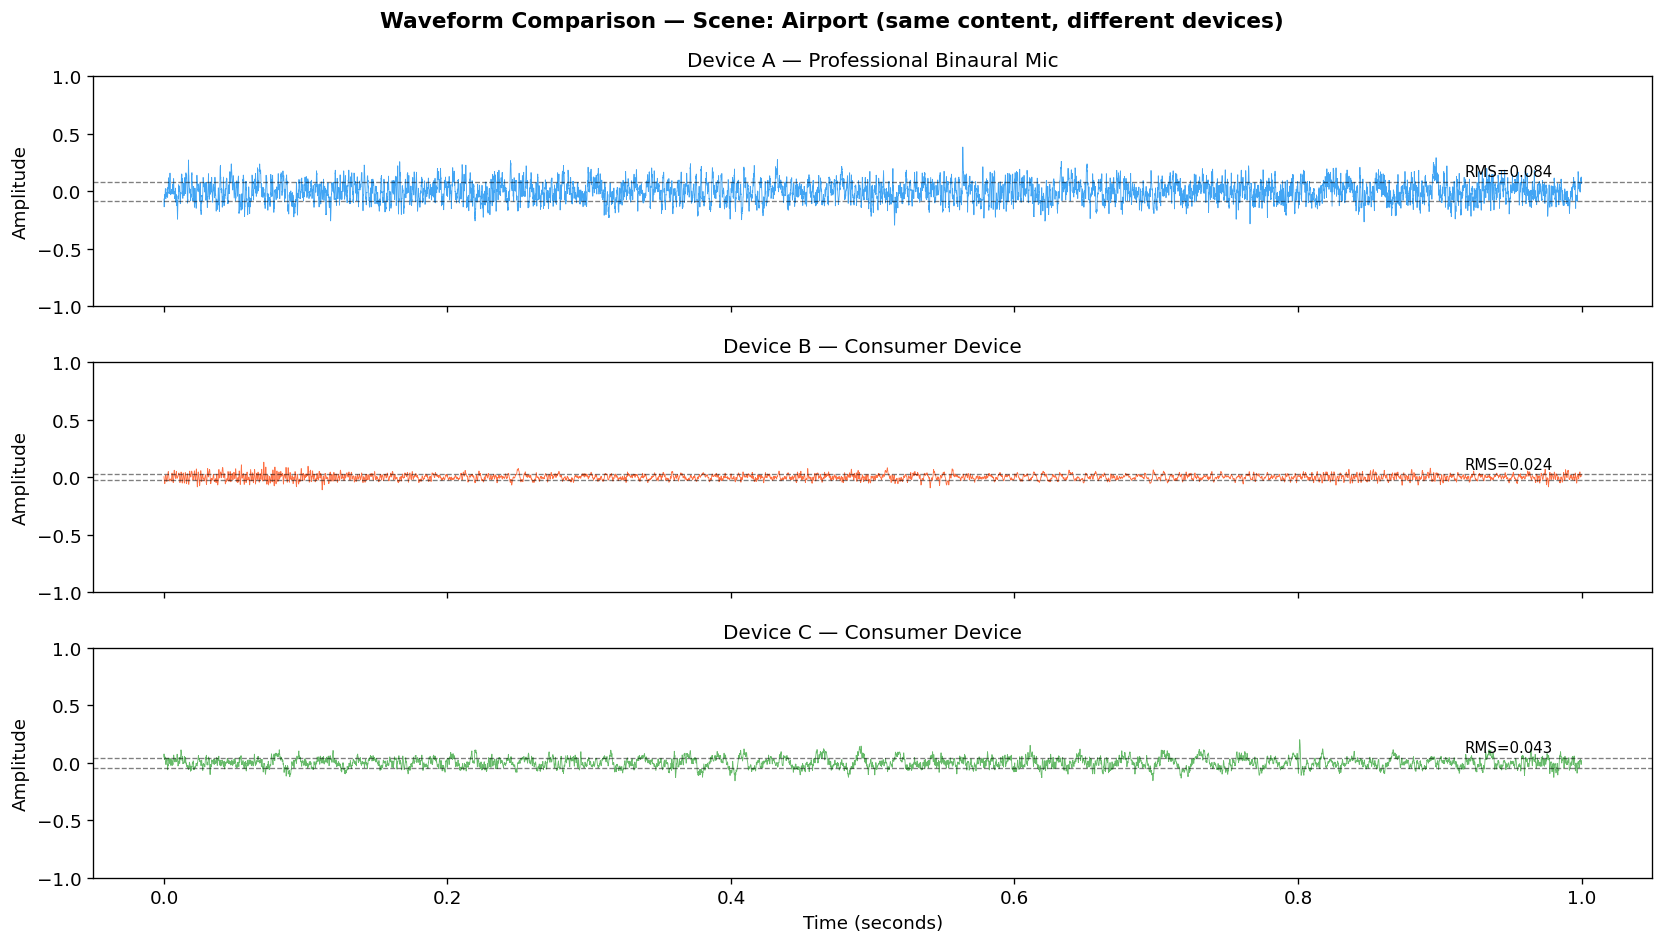

Saved → figures/04_waveform_comparison.png
Notice: amplitude levels and noise floor differ visibly across devices.


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
device_names = {'a': 'Device A — Professional Binaural Mic',
                'b': 'Device B — Consumer Device',
                'c': 'Device C — Consumer Device'}
t = np.linspace(0, 1, SR)

for ax, device in zip(axes, DEVICES):
    audio = audio_samples[device]
    ax.plot(t, audio, color=DEVICE_COLORS[device], linewidth=0.5, alpha=0.85)
    ax.set_ylabel('Amplitude')
    ax.set_title(device_names[device])
    ax.set_ylim(-1, 1)
    # Mark RMS energy
    rms = np.sqrt(np.mean(audio**2))
    ax.axhline(rms, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(-rms, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(0.98, rms + 0.05, f'RMS={rms:.3f}', ha='right', transform=ax.transData, fontsize=9)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle(f'Waveform Comparison — Scene: {SCENE.title()} (same content, different devices)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/04_waveform_comparison.png')
print('Notice: amplitude levels and noise floor differ visibly across devices.')

---
## 4. Mel Spectrogram Comparison — Figure 1 of Paper

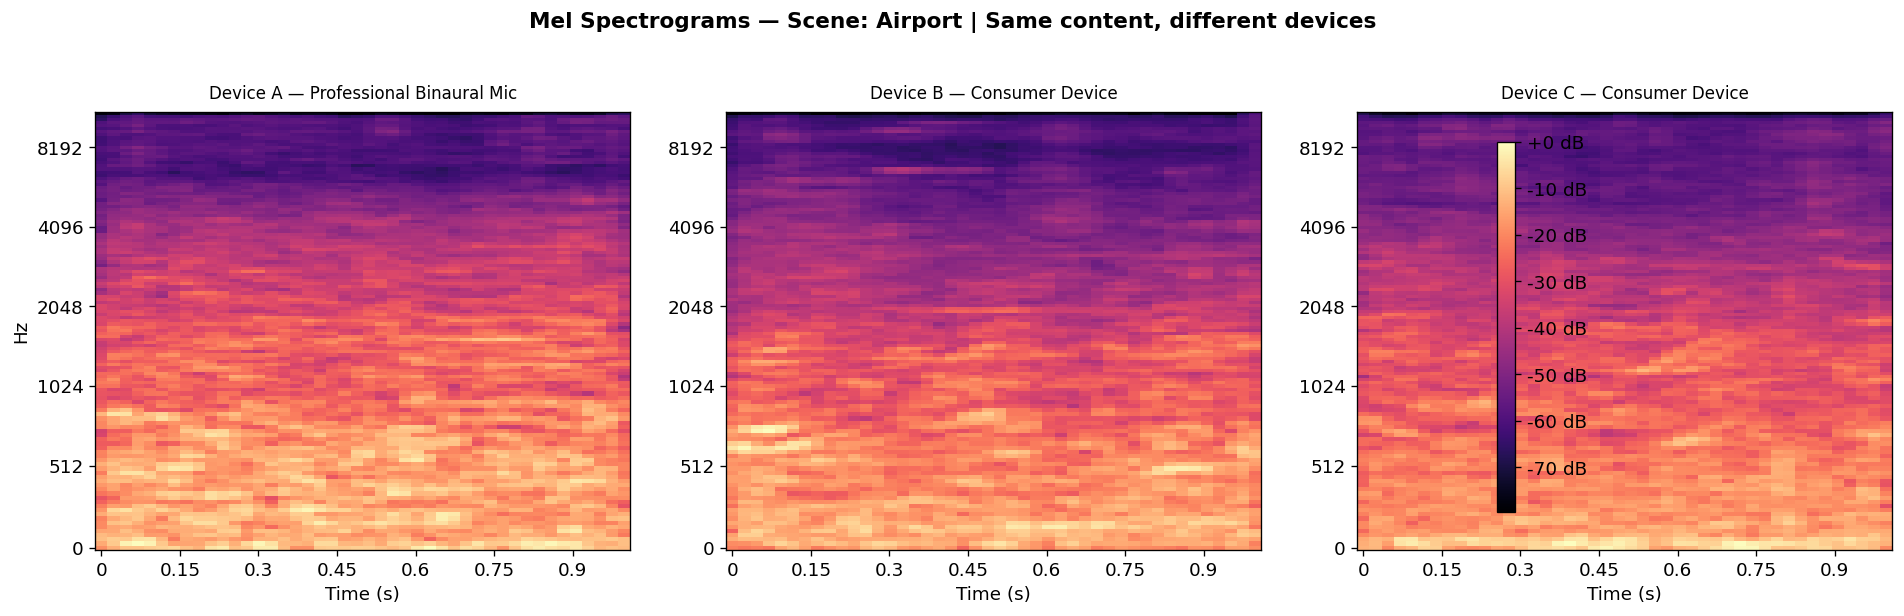

Saved → figures/05_mel_spectrogram_comparison.png  ← THIS IS FIGURE 1 OF YOUR PAPER

Observation: Device A shows richer high-frequency content (brighter top half).
Devices B and C show attenuation in high frequencies — darker top regions.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mels = {}

for ax, device in zip(axes, DEVICES):
    audio = audio_samples[device]
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, fmax=SR//2)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mels[device] = mel_db
    img = librosa.display.specshow(mel_db, ax=ax, sr=SR,
                                   x_axis='time', y_axis='mel', fmax=SR//2)
    ax.set_title(device_names[device], fontsize=10, pad=8)
    ax.set_xlabel('Time (s)')
    if device != 'a':
        ax.set_ylabel('')

plt.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.8)
fig.suptitle(f'Mel Spectrograms — Scene: {SCENE.title()} | Same content, different devices',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_mel_spectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_mel_spectrogram_comparison.png  ← THIS IS FIGURE 1 OF YOUR PAPER')
print('\nObservation: Device A shows richer high-frequency content (brighter top half).')
print('Devices B and C show attenuation in high frequencies — darker top regions.')

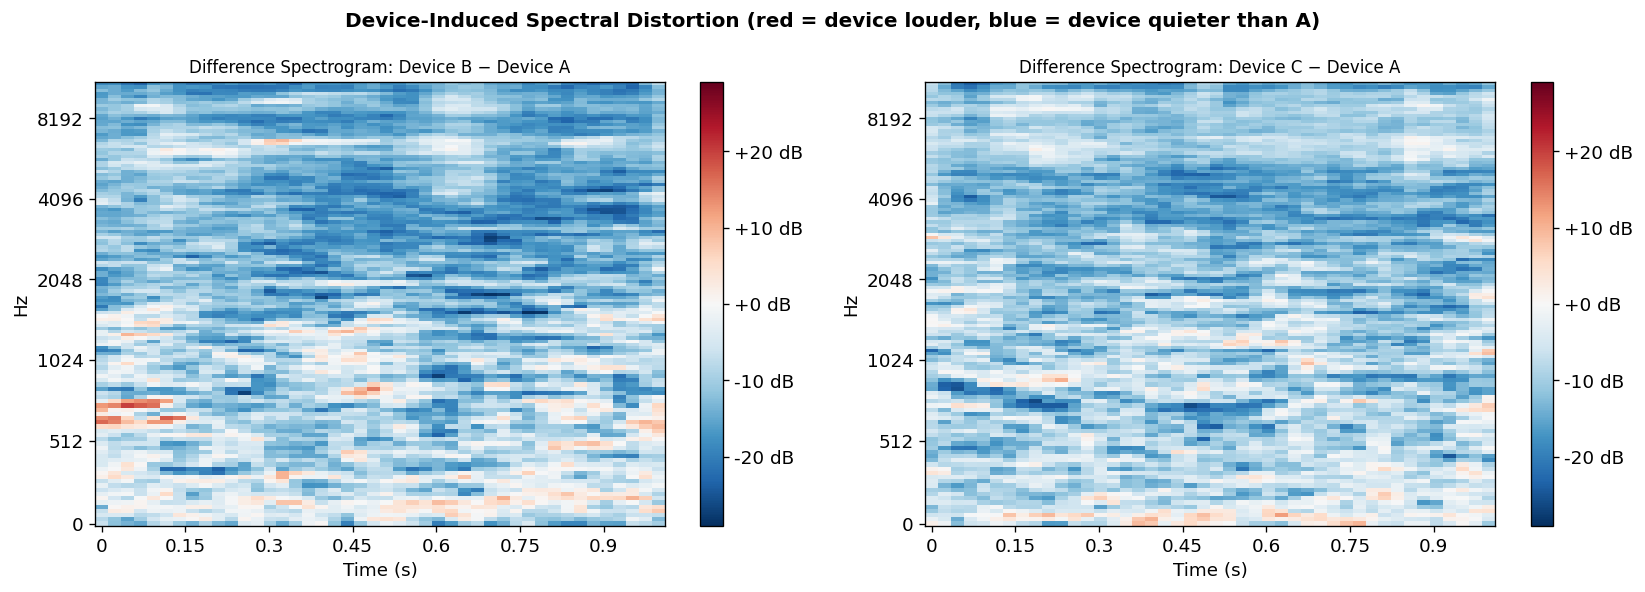

Saved → figures/06_difference_spectrograms.png

Key insight: The differences are SYSTEMATIC (same pattern across time),
which means they are device-induced — not content-dependent. This is what we exploit.


In [9]:
# Difference spectrograms — show EXACTLY what changes between devices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diff_BA = mels['b'] - mels['a']
diff_CA = mels['c'] - mels['a']

vmax = max(np.abs(diff_BA).max(), np.abs(diff_CA).max())

for ax, diff, label in zip(axes,
                           [diff_BA, diff_CA],
                           ['Device B − Device A', 'Device C − Device A']):
    img = librosa.display.specshow(diff, ax=ax, sr=SR,
                                   x_axis='time', y_axis='mel', fmax=SR//2,
                                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Difference Spectrogram: {label}', fontsize=10)
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

fig.suptitle('Device-Induced Spectral Distortion (red = device louder, blue = device quieter than A)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_difference_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/06_difference_spectrograms.png')
print('\nKey insight: The differences are SYSTEMATIC (same pattern across time),')
print('which means they are device-induced — not content-dependent. This is what we exploit.')

---
## 5. Frequency Response Analysis — The Core Physical Phenomenon

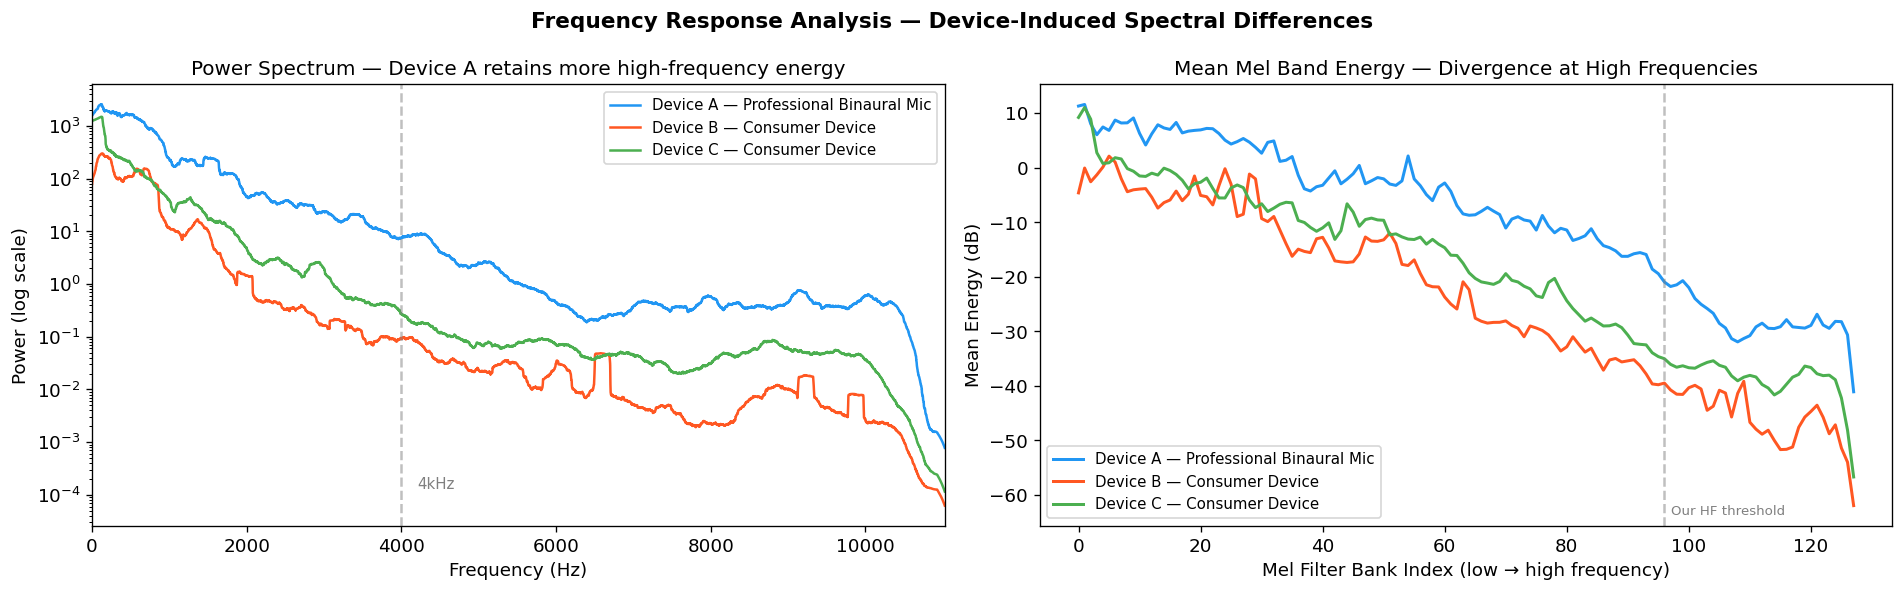

Saved → figures/07_frequency_response.png

This plot shows WHY signal features like spectral_rolloff and hf_lf_ratio
can distinguish devices — the energy curves diverge above ~4kHz.


In [10]:
# Average power spectrum per device — shows frequency response clearly
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: power spectrum overlay
freqs = np.fft.rfftfreq(SR, d=1/SR)
for device in DEVICES:
    audio = audio_samples[device]
    spectrum = np.abs(np.fft.rfft(audio))**2
    # Smooth with moving average
    window = 200
    smoothed = np.convolve(spectrum, np.ones(window)/window, mode='same')
    axes[0].semilogy(freqs[:len(smoothed)], smoothed,
                     color=DEVICE_COLORS[device], linewidth=1.5,
                     label=device_names[device])

axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (log scale)')
axes[0].set_title('Power Spectrum — Device A retains more high-frequency energy')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, SR//2)
axes[0].axvline(4000, color='gray', linestyle='--', alpha=0.5)
axes[0].text(4200, axes[0].get_ylim()[0]*5, '4kHz', fontsize=9, color='gray')

# Right: mel band energy per device
N_MELS = 128
mel_bands = np.arange(N_MELS)
for device in DEVICES:
    mel = librosa.feature.melspectrogram(y=audio_samples[device], sr=SR, n_mels=N_MELS)
    mean_energy = np.mean(mel, axis=1)  # average over time
    axes[1].plot(mel_bands, librosa.power_to_db(mean_energy),
                 color=DEVICE_COLORS[device], linewidth=1.8,
                 label=device_names[device])

axes[1].set_xlabel('Mel Filter Bank Index (low → high frequency)')
axes[1].set_ylabel('Mean Energy (dB)')
axes[1].set_title('Mean Mel Band Energy — Divergence at High Frequencies')
axes[1].legend(fontsize=9)
axes[1].axvline(96, color='gray', linestyle='--', alpha=0.5)
axes[1].text(97, axes[1].get_ylim()[0]+2, 'Our HF threshold', fontsize=8, color='gray')

fig.suptitle('Frequency Response Analysis — Device-Induced Spectral Differences',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_frequency_response.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/07_frequency_response.png')
print('\nThis plot shows WHY signal features like spectral_rolloff and hf_lf_ratio')
print('can distinguish devices — the energy curves diverge above ~4kHz.')

---
## 6. Signal Feature Extraction & Validation — Figure 2 of Paper

In [11]:
# Extract features from a single clip
print('Signal features for the SAME airport scene across devices:\n')
print(f'{"Feature":<25} {"Device A":>12} {"Device B":>12} {"Device C":>12} {"A→B diff":>10}')
print('─' * 75)

feats = {d: extract_device_features(audio_samples[d], SR) for d in DEVICES}
for i, name in enumerate(FEATURE_NAMES):
    vals = [feats[d][i] for d in DEVICES]
    diff = abs(vals[1] - vals[0]) / (abs(vals[0]) + 1e-8) * 100
    print(f'{name:<25} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>12.4f} {diff:>9.1f}%')

Signal features for the SAME airport scene across devices:

Feature                       Device A     Device B     Device C   A→B diff
───────────────────────────────────────────────────────────────────────────
spectral_centroid            1560.0298    1035.1598    1187.1896      33.6%
spectral_rolloff_85          3060.1619    1708.2192    2161.1506      44.2%
noise_floor                     0.0020       0.0004       0.0006      80.6%
spectral_flatness               0.0095       0.0016       0.0033      82.9%
hf_lf_ratio                     0.0004       0.0001       0.0001      80.9%


In [12]:
# Compute features across many clips per device for statistical validation
N_PER_DEVICE = 30
print(f'Computing signal features across {N_PER_DEVICE} clips per device...')

all_feats = {d: [] for d in DEVICES}

for device in DEVICES:
    rows = meta[meta['device'] == device].sample(n=min(N_PER_DEVICE, sum(meta['device']==device)),
                                                  random_state=42)
    for _, row in rows.iterrows():
        path = os.path.join(AUDIO_DIR, row['filename'])
        if os.path.exists(path):
            audio, _ = librosa.load(path, sr=SR, mono=True, duration=1.0)
            if len(audio) < SR:
                audio = np.pad(audio, (0, SR - len(audio)))
            all_feats[device].append(extract_device_features(audio, SR))
    print(f'  Device {device.upper()}: {len(all_feats[device])} clips processed')

feat_arr  = {d: np.array(v) for d, v in all_feats.items() if v}
feat_mean = {d: np.mean(v, axis=0) for d, v in feat_arr.items()}
feat_std  = {d: np.std(v, axis=0)  for d, v in feat_arr.items()}
print('Done.')

Computing signal features across 30 clips per device...


  Device A: 30 clips processed


  Device B: 30 clips processed


  Device C: 30 clips processed
Done.


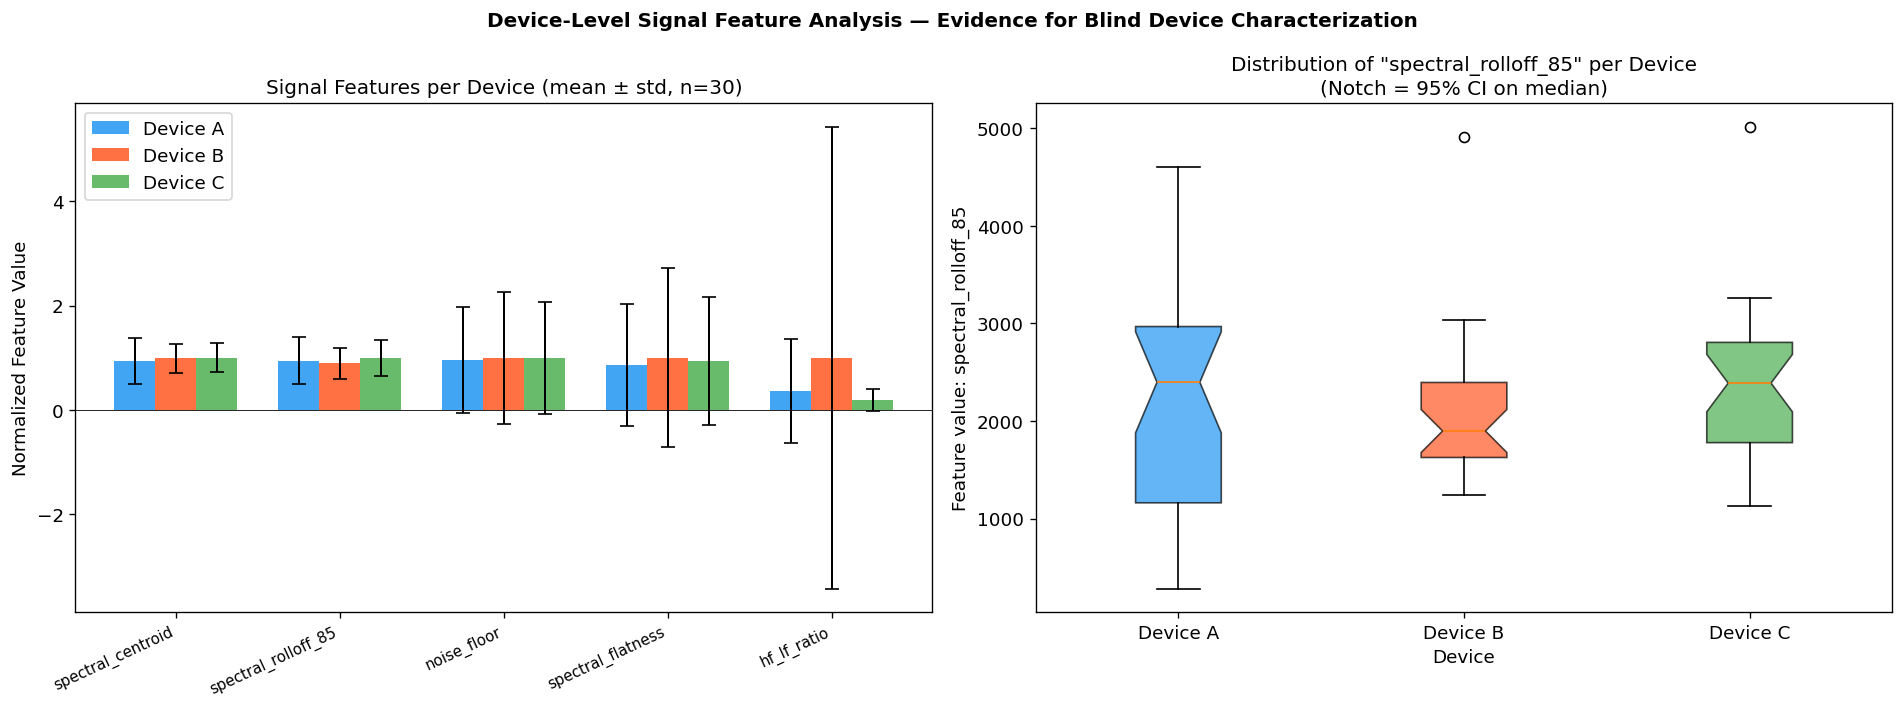

Saved → figures/08_signal_features_analysis.png  ← THIS IS FIGURE 2 OF YOUR PAPER

If the box plots for devices A, B, C do NOT overlap → strong discriminative signal.
Non-overlapping notches = statistically significant difference in medians.


In [13]:
# Figure 2: Signal features comparison with error bars
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(FEATURE_NAMES))
width = 0.25

# Left: grouped bar chart with error bars
for i, device in enumerate(DEVICES):
    means = feat_mean[device]
    stds  = feat_std[device]
    # Normalize each feature for visual comparison
    all_means = np.stack([feat_mean[d] for d in DEVICES])
    norm_means = means / (all_means.max(axis=0) + 1e-8)
    norm_stds  = stds  / (all_means.max(axis=0) + 1e-8)
    axes[0].bar(x + i*width, norm_means, width,
                label=f'Device {device.upper()}',
                color=DEVICE_COLORS[device], alpha=0.85,
                yerr=norm_stds, capsize=4, error_kw={'linewidth': 1.2})

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(FEATURE_NAMES, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Normalized Feature Value')
axes[0].set_title(f'Signal Features per Device (mean ± std, n={N_PER_DEVICE})')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)

# Right: box plots — show distributions, not just means
feat_idx = 1  # spectral_rolloff — most discriminative
box_data  = [feat_arr[d][:, feat_idx] for d in DEVICES]
bp = axes[1].boxplot(box_data, labels=[f'Device {d.upper()}' for d in DEVICES],
                     patch_artist=True, notch=True)
for patch, device in zip(bp['boxes'], DEVICES):
    patch.set_facecolor(DEVICE_COLORS[device])
    patch.set_alpha(0.7)
axes[1].set_ylabel(f'Feature value: {FEATURE_NAMES[feat_idx]}')
axes[1].set_title(f'Distribution of "{FEATURE_NAMES[feat_idx]}" per Device\n(Notch = 95% CI on median)')
axes[1].set_xlabel('Device')

fig.suptitle('Device-Level Signal Feature Analysis — Evidence for Blind Device Characterization',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/08_signal_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/08_signal_features_analysis.png  ← THIS IS FIGURE 2 OF YOUR PAPER')
print('\nIf the box plots for devices A, B, C do NOT overlap → strong discriminative signal.')
print('Non-overlapping notches = statistically significant difference in medians.')

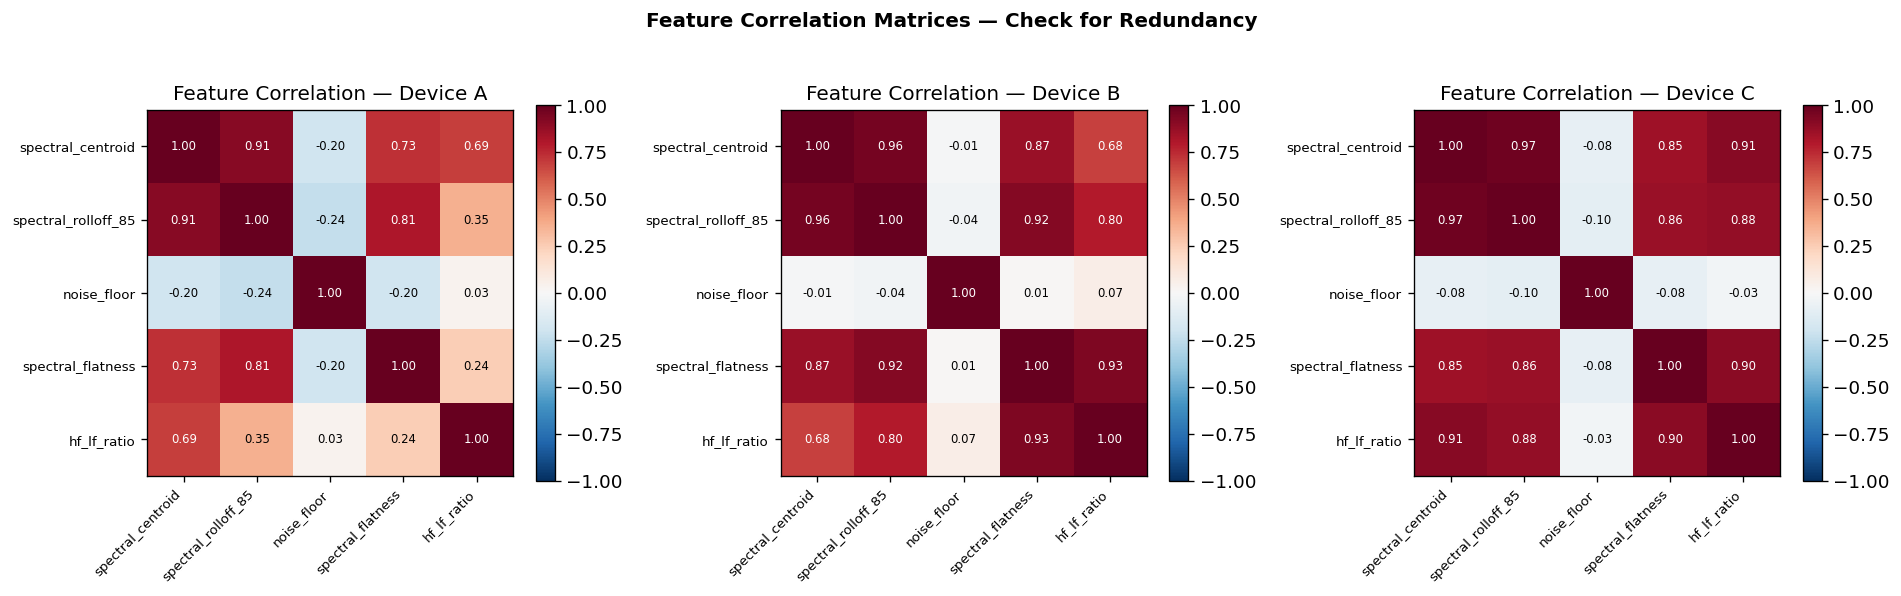

Saved → figures/09_feature_correlation.png

High correlation (|r| > 0.8) between features = redundancy = can drop one.
Low correlation = each feature adds independent information = keep all.


In [14]:
# Correlation matrix of features — understand redundancy before design
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, device in zip(axes, DEVICES):
    corr = np.corrcoef(feat_arr[device].T)
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(FEATURE_NAMES)))
    ax.set_yticks(range(len(FEATURE_NAMES)))
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
    ax.set_title(f'Feature Correlation — Device {device.upper()}')
    for i in range(len(FEATURE_NAMES)):
        for j in range(len(FEATURE_NAMES)):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(corr[i,j]) > 0.6 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Feature Correlation Matrices — Check for Redundancy',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/09_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/09_feature_correlation.png')
print('\nHigh correlation (|r| > 0.8) between features = redundancy = can drop one.')
print('Low correlation = each feature adds independent information = keep all.')

---
## 7. Scene-wise Signal Feature Analysis — Does device effect vary by scene?

In [15]:
# Key question: are signal features device-consistent across ALL scenes?
# If yes → they are scene-invariant device fingerprints → our hypothesis is valid

SCENES = meta['scene_label'].unique()[:5]  # first 5 scenes for speed
FEAT_IDX = 1  # spectral_rolloff
N_PER_SCENE = 10

print(f'Computing "{FEATURE_NAMES[FEAT_IDX]}" across {len(SCENES)} scenes × 3 devices...')

scene_feat_data = {scene: {d: [] for d in DEVICES} for scene in SCENES}

for scene in SCENES:
    scene_meta = meta[meta['scene_label'] == scene]
    for device in DEVICES:
        rows = scene_meta[scene_meta['device'] == device].head(N_PER_SCENE)
        for _, row in rows.iterrows():
            path = os.path.join(AUDIO_DIR, row['filename'])
            if os.path.exists(path):
                audio, _ = librosa.load(path, sr=SR, mono=True, duration=1.0)
                if len(audio) < SR:
                    audio = np.pad(audio, (0, SR - len(audio)))
                feat = extract_device_features(audio, SR)
                scene_feat_data[scene][device].append(feat[FEAT_IDX])

print('Done.')

Computing "spectral_rolloff_85" across 5 scenes × 3 devices...


Done.


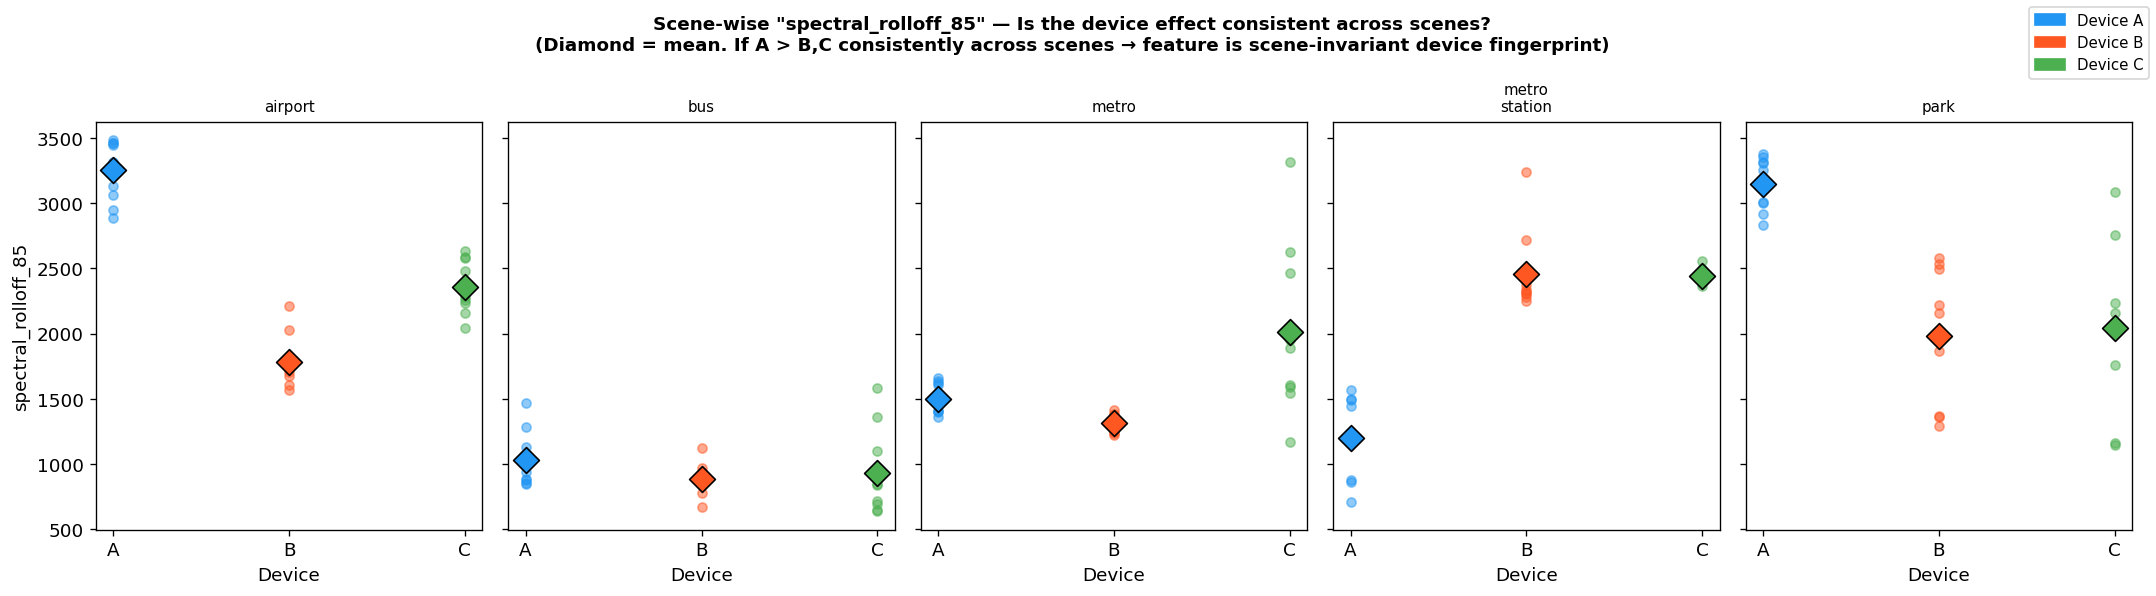

Saved → figures/10_scene_wise_features.png

Critical result: If Device A is consistently higher/lower than B and C
across ALL scenes → the feature captures the device, not the scene.
This is the core empirical justification for our method.


In [16]:
fig, axes = plt.subplots(1, len(SCENES), figsize=(18, 5), sharey=True)

for ax, scene in zip(axes, SCENES):
    for device in DEVICES:
        vals = scene_feat_data[scene][device]
        if vals:
            ax.scatter([device.upper()] * len(vals), vals,
                      color=DEVICE_COLORS[device], alpha=0.5, s=30)
            ax.scatter([device.upper()], [np.mean(vals)],
                      color=DEVICE_COLORS[device], s=120, marker='D',
                      edgecolors='black', linewidth=1, zorder=5)
    ax.set_title(scene.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Device')

axes[0].set_ylabel(f'{FEATURE_NAMES[FEAT_IDX]}')
legend_handles = [mpatches.Patch(color=DEVICE_COLORS[d],
                                  label=f'Device {d.upper()}') for d in DEVICES]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)
fig.suptitle(f'Scene-wise "{FEATURE_NAMES[FEAT_IDX]}" — Is the device effect consistent across scenes?\n'
             f'(Diamond = mean. If A > B,C consistently across scenes → feature is scene-invariant device fingerprint)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/10_scene_wise_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/10_scene_wise_features.png')
print('\nCritical result: If Device A is consistently higher/lower than B and C')
print('across ALL scenes → the feature captures the device, not the scene.')
print('This is the core empirical justification for our method.')

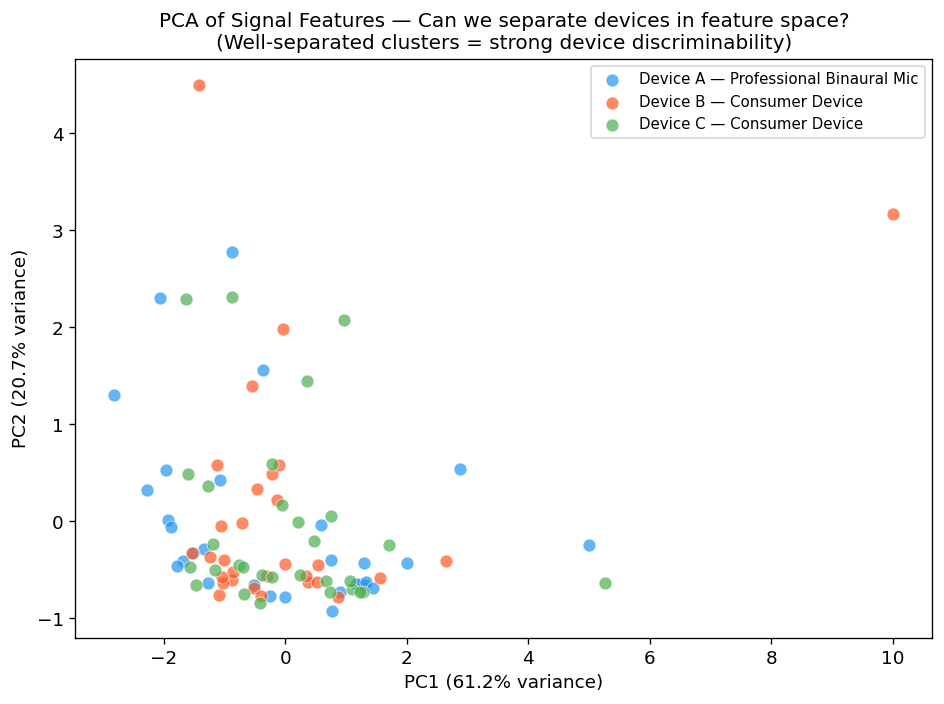

Saved → figures/11_pca_device_separation.png
PC1 + PC2 explain 81.9% of variance.
If devices cluster separately → our 5 features carry strong device identity signal.


In [17]:
# PCA scatter — can we visually separate devices in feature space?
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Stack all features with device labels
X_all, y_all = [], []
for device in DEVICES:
    X_all.append(feat_arr[device])
    y_all.extend([device] * len(feat_arr[device]))
X_all = np.vstack(X_all)

X_scaled = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for device in DEVICES:
    mask = np.array(y_all) == device
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=DEVICE_COLORS[device], alpha=0.7, s=60,
               label=device_names[device], edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of Signal Features — Can we separate devices in feature space?\n'
             '(Well-separated clusters = strong device discriminability)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/11_pca_device_separation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/11_pca_device_separation.png')
print(f'PC1 + PC2 explain {sum(pca.explained_variance_ratio_[:2])*100:.1f}% of variance.')
print('If devices cluster separately → our 5 features carry strong device identity signal.')

---
## 8. Model Parameter Check — DCASE Compliance

In [18]:
import torch
from src.classifier.model import CPMobile

baseline_model = CPMobile(n_classes=10, signal_feat_dim=0)
our_model      = CPMobile(n_classes=10, signal_feat_dim=5)

print('='*45)
print(f'DCASE parameter limit:    128,000')
print(f'Baseline model params:    {baseline_model.count_parameters():>7,}')
print(f'Our model params (+5 sig):{our_model.count_parameters():>7,}')
print(f'Overhead from our feats:  {our_model.count_parameters()-baseline_model.count_parameters():>7,}')
print(f'Within limit (ours):      {our_model.count_parameters() < 128000}')
print('='*45)

# Test forward pass
dummy_mel   = torch.randn(2, 1, 128, 44)
dummy_feats = torch.randn(2, 5)
out = our_model(dummy_mel, dummy_feats)
print(f'Forward pass output shape: {out.shape}  (batch=2, classes=10) ✓')

DCASE parameter limit:    128,000
Baseline model params:     10,186
Our model params (+5 sig): 10,236
Overhead from our feats:       50
Within limit (ours):      True
Forward pass output shape: torch.Size([2, 10])  (batch=2, classes=10) ✓


In [19]:
# Summary plot of all saved figures
figs = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
print('All figures generated:')
for f in figs:
    size = os.path.getsize(os.path.join(FIGURES_DIR, f)) // 1024
    print(f'  {f}  ({size} KB)')
print(f'\nTotal: {len(figs)} figures ready for paper.')

All figures generated:
  01_dataset_distribution.png  (120 KB)
  02_city_distribution.png  (55 KB)
  03_scene_device_heatmap.png  (92 KB)
  04_waveform_comparison.png  (268 KB)
  05_mel_spectrogram_comparison.png  (137 KB)
  06_difference_spectrograms.png  (113 KB)
  07_frequency_response.png  (240 KB)
  08_signal_features_analysis.png  (128 KB)
  09_feature_correlation.png  (133 KB)
  10_scene_wise_features.png  (114 KB)
  11_pca_device_separation.png  (90 KB)

Total: 11 figures ready for paper.
